📌 1. Install & Import Libraries

In [ ]:
!pip install xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score

import xgboost as xgb
import shap

📌 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/application_train.csv')

print("Original Shape:", df.shape)

Original Shape: (100253, 122)


📌 3. Select ONLY Required Columns

In [ ]:
# Core selected columns
selected_columns = [
    # Financial
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',

    # Demographics
    'CODE_GENDER', 'CNT_CHILDREN', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE',

    # Behavioral
    'DAYS_EMPLOYED', 'DAYS_BIRTH', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',

    # Stability
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE',

    # Target
    'TARGET'
]

# Automatically include all credit bureau columns
bureau_cols = [col for col in df.columns if 'AMT_REQ_CREDIT_BUREAU' in col]

# Final column list
final_cols = selected_columns + bureau_cols

# Filter dataset
df = df[final_cols]

print("Filtered Shape:", df.shape)
df.head()

Filtered Shape: (100253, 22)


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CODE_GENDER,CNT_CHILDREN,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,DAYS_EMPLOYED,DAYS_BIRTH,...,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,TARGET,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,202500.0,406597.5,24700.5,351000.0,M,0,Single / not married,Secondary / secondary special,-637,-9461,...,N,Y,House / apartment,1,0.0,0.0,0.0,0.0,0.0,1.0
1,270000.0,1293502.5,35698.5,1129500.0,F,0,Married,Higher education,-1188,-16765,...,N,N,House / apartment,0,0.0,0.0,0.0,0.0,0.0,0.0
2,67500.0,135000.0,6750.0,135000.0,M,0,Single / not married,Secondary / secondary special,-225,-19046,...,Y,Y,House / apartment,0,0.0,0.0,0.0,0.0,0.0,0.0
3,135000.0,312682.5,29686.5,297000.0,F,0,Civil marriage,Secondary / secondary special,-3039,-19005,...,N,Y,House / apartment,0,NaN,NaN,NaN,NaN,NaN,NaN
4,121500.0,513000.0,21865.5,513000.0,M,0,Single / not married,Secondary / secondary special,-3038,-19932,...,N,Y,House / apartment,0,0.0,0.0,0.0,0.0,0.0,0.0


📌 4. Check Missing Values

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

OCCUPATION_TYPE               31309
AMT_REQ_CREDIT_BUREAU_DAY     13472
AMT_REQ_CREDIT_BUREAU_QRT     13472
AMT_REQ_CREDIT_BUREAU_YEAR    13472
AMT_REQ_CREDIT_BUREAU_MON     13472
AMT_REQ_CREDIT_BUREAU_WEEK    13472
AMT_REQ_CREDIT_BUREAU_HOUR    13472
AMT_GOODS_PRICE                  81
AMT_ANNUITY                       7
AMT_CREDIT                        0
CNT_CHILDREN                      0
CODE_GENDER                       0
AMT_INCOME_TOTAL                  0
NAME_FAMILY_STATUS                0
FLAG_OWN_REALTY                   0
FLAG_OWN_CAR                      0
ORGANIZATION_TYPE                 0
DAYS_BIRTH                        0
NAME_EDUCATION_TYPE               0
DAYS_EMPLOYED                     0
NAME_HOUSING_TYPE                 0
TARGET                            0
dtype: int64


In [ ]:
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

/tmp/ipykernel_5327/806898358.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


📌 5. Handle Missing Values (SMART IMPUTATION)

In [ ]:
# Separate types
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Remove TARGET from numeric columns
# Ensure 'TARGET' is in num_cols before attempting to drop it
if 'TARGET' in num_cols:
    num_cols = num_cols.drop('TARGET')

# Numeric → Median
num_imputer = SimpleImputer(strategy='median')
# Only impute if there are numeric columns to process
if not num_cols.empty:
    df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical → Most Frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
# Only impute if there are categorical columns to process
if not cat_cols.empty:
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                   0
AMT_GOODS_PRICE               0
CODE_GENDER                   0
CNT_CHILDREN                  0
NAME_FAMILY_STATUS            0
NAME_EDUCATION_TYPE           0
DAYS_EMPLOYED                 0
DAYS_BIRTH                    0
OCCUPATION_TYPE               0
ORGANIZATION_TYPE             0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
NAME_HOUSING_TYPE             0
TARGET                        0
AMT_REQ_CREDIT_BUREAU_HOUR    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
dtype: int64


📌 6. Encode Categorical Variables

In [ ]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

📌 7. Feature Scaling

In [ ]:
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

📌 8. Train-Test Split

In [ ]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

📌 9. Train XGBoost Model

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

📌 10. Model Evaluation

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9204681473600212
AUC: 0.6680832676735388


📌 11. Visualization

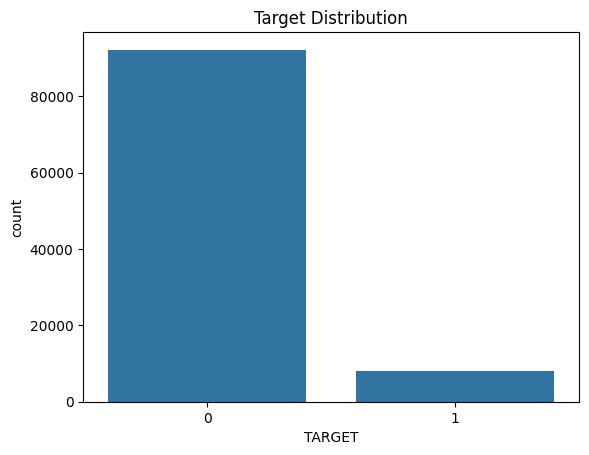

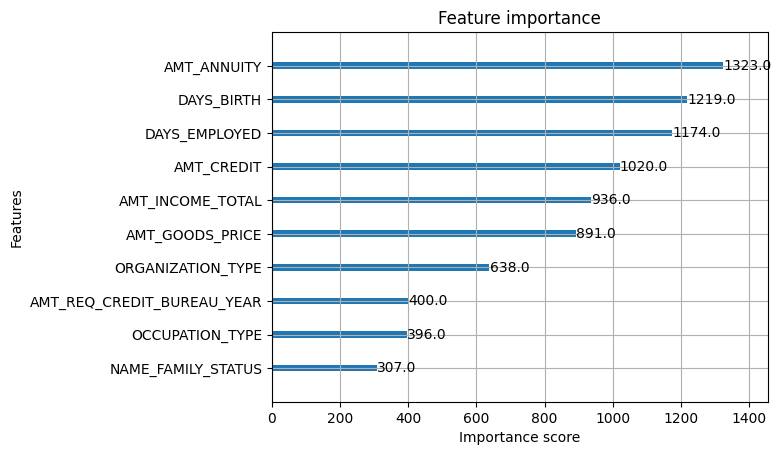

In [ ]:
# Target Distribution
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

# Feature Importance
xgb.plot_importance(model, max_num_features=10)
plt.show()

📌 12. SHAP Explainability

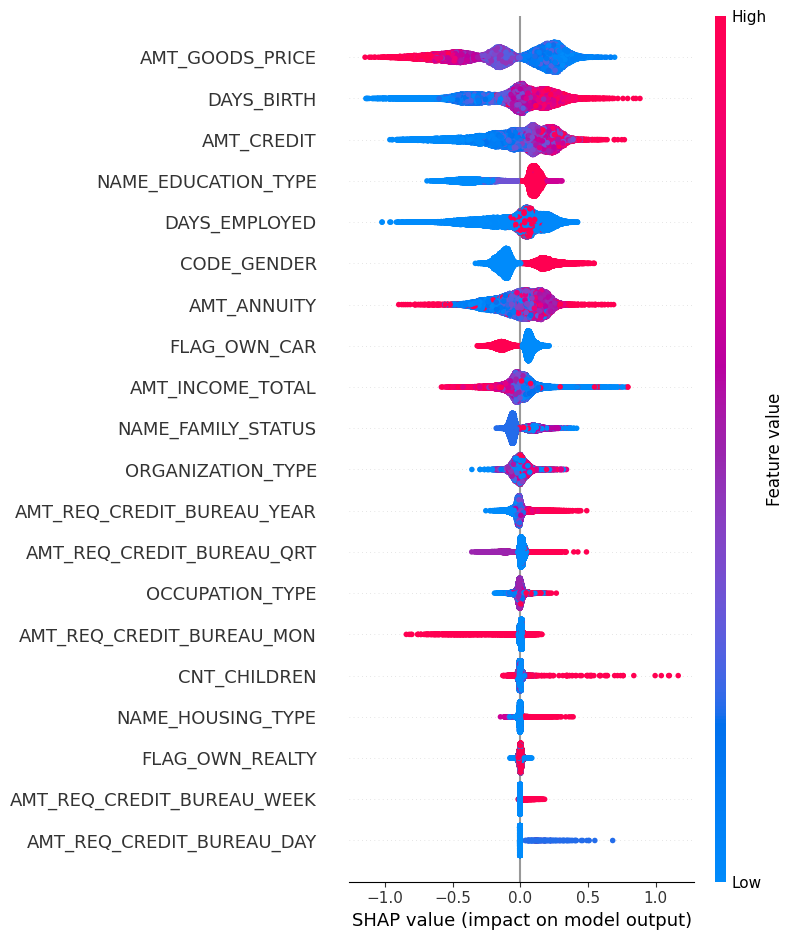

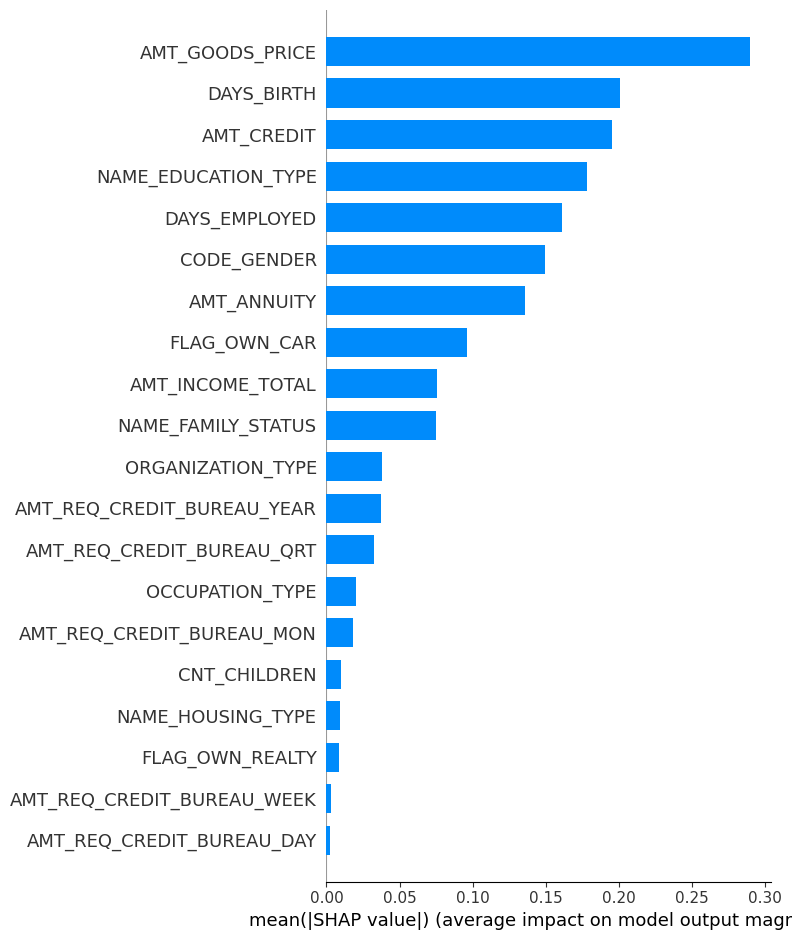

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(shap_values, X_test)

# Feature Importance (Bar)
shap.summary_plot(shap_values, X_test, plot_type="bar")

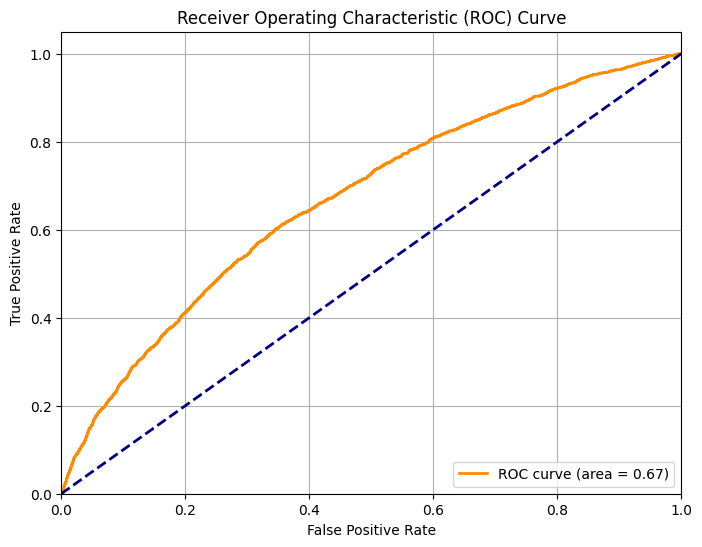

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_prob))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

I've plotted the Receiver Operating Characteristic (ROC) curve. This curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The area under the curve (AUC) is approximately 0.67, which indicates the model's ability to distinguish between the positive and negative classes. A higher AUC means a better model performance.

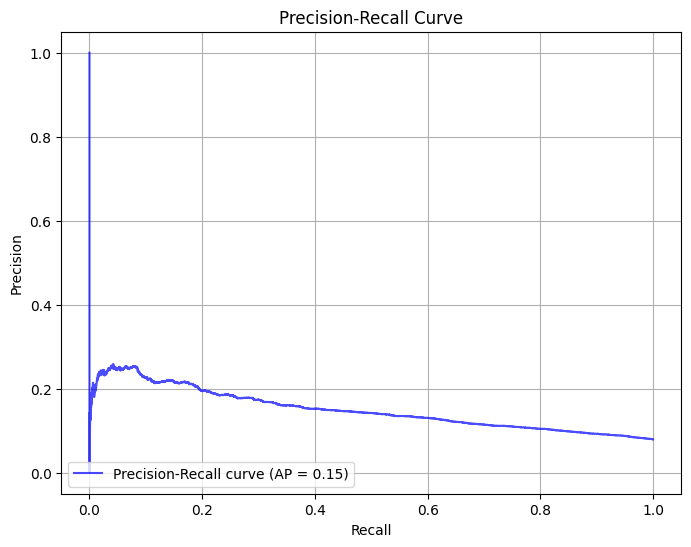

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Calculate average precision score
aps = average_precision_score(y_test, y_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', alpha=0.7, label=f'Precision-Recall curve (AP = {aps:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

I have created the Precision-Recall curve for the model. The Average Precision Score (APS) for this model is approximately 0.15. The Precision-Recall curve illustrates the trade-off between precision and recall for different thresholds. This curve is particularly useful when dealing with imbalanced datasets, as it focuses on the performance of the model on the positive class.

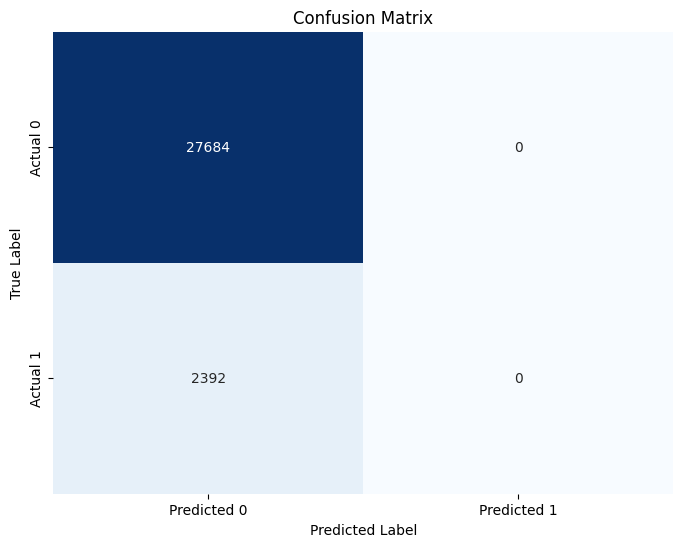

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

 From this matrix, we can observe that the model correctly identified 27,684 instances of class 0 (True Negatives) and 0 instances of class 1 (True Positives). However, it incorrectly classified 2,392 instances of class 1 as class 0 (False Negatives) and 0 instances of class 0 as class 1 (False Positives). This indicates that the model is predicting '0' for almost all instances, which is common in highly imbalanced datasets where the minority class (class 1) is very difficult to predict.

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred)

# Print the report
print(report)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     27684
           1       0.00      0.00      0.00      2392

    accuracy                           0.92     30076
   macro avg       0.46      0.50      0.48     30076
weighted avg       0.85      0.92      0.88     30076



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

print("Original class distribution:")
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nResampled class distribution:")
print(y_train_res.value_counts())

Original class distribution:
TARGET
0    64459
1     5718
Name: count, dtype: int64

Resampled class distribution:
TARGET
0    64459
1    64459
Name: count, dtype: int64


In [ ]:
model_resampled = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,  # Increased max_depth to capture more complex patterns
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=0.1 # Decreased min_child_weight to make model more sensitive to minority class
)

model_resampled.fit(X_train_res, y_train_res)

y_pred_resampled = model_resampled.predict(X_test)
y_prob_resampled = model_resampled.predict_proba(X_test)[:,1]

print("Accuracy (Resampled Data):", accuracy_score(y_test, y_pred_resampled))
print("AUC (Resampled Data):", roc_auc_score(y_test, y_prob_resampled))
print("\nClassification Report (Resampled Data):\n", classification_report(y_test, y_pred_resampled))

Accuracy (Resampled Data): 0.9108591568027663
AUC (Resampled Data): 0.6201237635783489

Classification Report (Resampled Data):
               precision    recall  f1-score   support

           0       0.92      0.99      0.95     27684
           1       0.18      0.03      0.06      2392

    accuracy                           0.91     30076
   macro avg       0.55      0.51      0.51     30076
weighted avg       0.86      0.91      0.88     30076



Feature Importance for the Resampled Model:


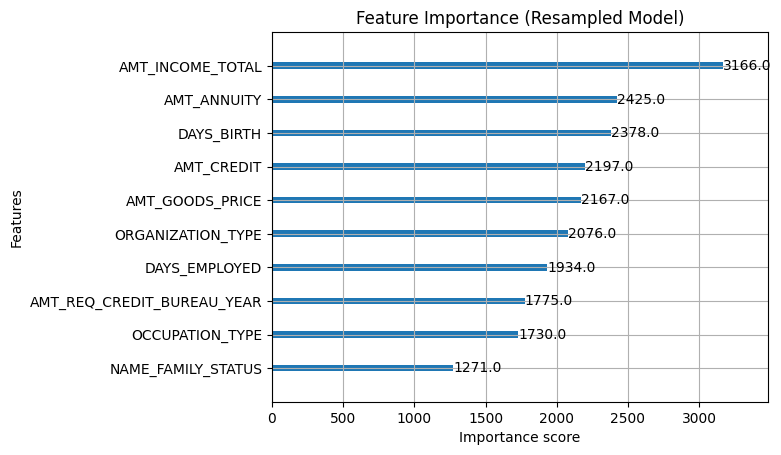

In [ ]:
print("Feature Importance for the Resampled Model:")
xgb.plot_importance(model_resampled, max_num_features=10)
plt.title("Feature Importance (Resampled Model)")
plt.show()